In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
data = pd.read_csv('../data/raw/cert_energ_andalucia.csv')

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199022 entries, 0 to 1199021
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   municipio              1198891 non-null  object 
 1   provincia              1199016 non-null  object 
 2   zona_climatica         1199021 non-null  object 
 3   ano_construccion       1197474 non-null  object 
 4   normativa              1195429 non-null  object 
 5   tipo_edificio          1199021 non-null  object 
 6   superficie             1199022 non-null  float64
 7   compacidad             1199022 non-null  float64
 8   pct_calefactado        1199022 non-null  int64  
 9   pct_refrigerado        1199022 non-null  int64  
 10  ventana_norte          1199022 non-null  float64
 11  ventana_sur            1199022 non-null  float64
 12  ventana_este           1199022 non-null  float64
 13  ventana_oeste          1199022 non-null  float64
 14  tipo_generador_cal

In [19]:
data.nunique()

municipio                13055
provincia                  117
zona_climatica              14
ano_construccion          1180
normativa                 2148
tipo_edificio                5
superficie               47362
compacidad                3040
pct_calefactado            195
pct_refrigerado            166
ventana_norte              237
ventana_sur                249
ventana_este               101
ventana_oeste              101
tipo_generador_cal          95
rendimiento_cal           3434
vector_energetico_cal        0
autoconsumo_elec         44230
consumo_global           47598
demanda_calefaccion      26525
demanda_refrigeracion    10568
emisiones_global         12154
clase_consumo                7
dtype: int64

In [20]:
cols_categoricas = [
    'provincia', 'zona_climatica', 'normativa', 
    'tipo_edificio', 'clase_consumo', 'tipo_generador_cal', 'vector_energetico_cal'
]

for col in cols_categoricas:
    data[col] = data[col].astype('category')

In [21]:
data.ano_construccion.value_counts().sort_index()

ano_construccion
\t1960                  5
\t1966                  1
\t1968                  3
\t1970                  3
\t1972                  1
                       ..
posterior a 2016        1
proyecto                1
proyecto, obra nueva    1
s XVIII                 1
s/d                     2
Name: count, Length: 1180, dtype: int64

In [22]:
# 1. Convertimos a string para poder manipularlo
data['ano_construccion'] = data['ano_construccion'].astype(str)

# 2. Extraemos solo los dígitos (ej. "1960" de "1960\t5")
# Esta regex busca grupos de 4 números seguidos
data['ano_limpio'] = data['ano_construccion'].str.extract(r'(\d{4})')

# 3. Convertimos a numérico (lo que no sea año se volverá NaN automáticamente)
data['ano_limpio'] = pd.to_numeric(data['ano_limpio'], errors='coerce')

Text(0.5, 1.0, 'Distribución del Año de Construcción')

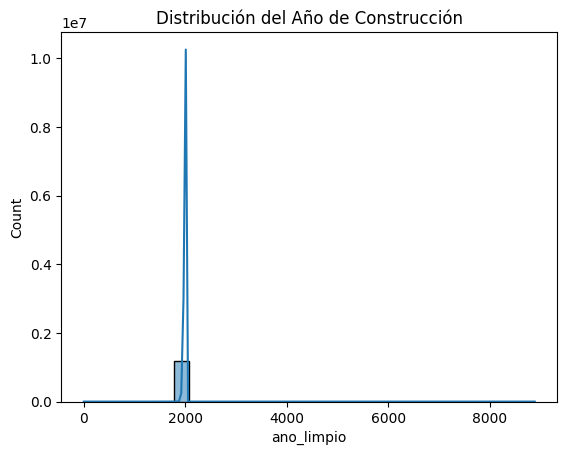

In [23]:
sns.histplot(data['ano_limpio'], bins=30, kde=True)
plt.title('Distribución del Año de Construcción')

In [24]:
data.ano_limpio.isna().sum()

6324

In [25]:
data[(data.ano_limpio < 2026) & (data.ano_limpio > 1700)].shape[0]

1192095

In [26]:
data.loc[(data.ano_limpio >= 2026), 'ano_limpio'] = np.nan
data.loc[(data.ano_limpio <= 1700), 'ano_limpio'] = np.nan

Text(0.5, 1.0, 'Distribución del Año de Construcción')

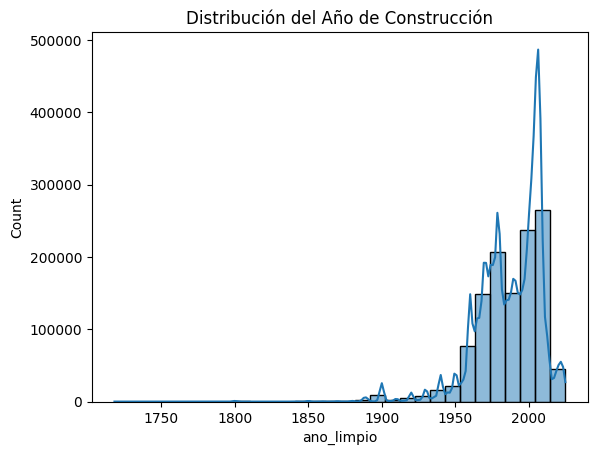

In [27]:
sns.histplot(data['ano_limpio'], bins=30, kde=True)
plt.title('Distribución del Año de Construcción')

In [28]:
data['ano_construccion'] = data['ano_limpio']
data.drop(columns=['ano_limpio'], inplace=True)

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199022 entries, 0 to 1199021
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   municipio              1198891 non-null  object  
 1   provincia              1199016 non-null  category
 2   zona_climatica         1199021 non-null  category
 3   ano_construccion       1192095 non-null  float64 
 4   normativa              1195429 non-null  category
 5   tipo_edificio          1199021 non-null  category
 6   superficie             1199022 non-null  float64 
 7   compacidad             1199022 non-null  float64 
 8   pct_calefactado        1199022 non-null  int64   
 9   pct_refrigerado        1199022 non-null  int64   
 10  ventana_norte          1199022 non-null  float64 
 11  ventana_sur            1199022 non-null  float64 
 12  ventana_este           1199022 non-null  float64 
 13  ventana_oeste          1199022 non-null  float64 
 14  ti

Para no perder ninguna variable, que me puede servir para el análisis de BI, voy a separar los datos en 5 tablas que se unan por un id como PK. De esta forma, separaré target o variables que puedan introducir data leakage al modelo de ML.

In [30]:
data['id_edificio'] = data.index

In [31]:
# 1. Características (Variables predictoras)
# Todas estas columnas existen en tu dataset
df_caract = data[['id_edificio', 'municipio', 'provincia', 'zona_climatica', 
                  'ano_construccion', 'normativa', 'tipo_edificio', 'superficie', 
                  'compacidad', 'pct_calefactado', 'pct_refrigerado', 
                  'ventana_norte', 'ventana_sur', 'ventana_este', 'ventana_oeste', 
                  'tipo_generador_cal']].copy()

# 2. Demandas
# Solo incluimos las que aparecen en el info()
df_demandas = data[['id_edificio', 'rendimiento_cal', 'demanda_calefaccion', 
                    'demanda_refrigeracion']].copy()

# 3. Consumos 
# Solo 'consumo_global' está disponible
df_consumos = data[['id_edificio', 'consumo_global']].copy()

# 4. Emisiones 
# Solo 'emisiones_global' está disponible
df_emisiones = data[['id_edificio', 'emisiones_global']].copy()

# 5. Clases 
# Solo 'clase_consumo' está disponible
df_clases = data[['id_edificio', 'clase_consumo']].copy()

In [32]:
df_caract.to_csv('../data/clean/pre_clean/caracteristicas_edificios.csv', index=False)
df_demandas.to_csv('../data/clean/pre_clean/demandas_energeticas.csv', index=False)
df_consumos.to_csv('../data/clean/pre_clean/consumos_energeticos.csv', index=False)
df_emisiones.to_csv('../data/clean/pre_clean/emisiones_ambientales.csv', index=False)
df_clases.to_csv('../data/clean/pre_clean/clases_edificios.csv', index=False)